# Thesis Capstone: Statistical Hypothesis Testing & Financial ROI Simulation
### Olist Brazilian E-Commerce MSc Data Science Dissertation

## 1. Chapter Objectives:
This final notebook provides the quantitative validation and business impact framework for this master's dissertation:
1. **Statistical Significance Testing**:
   - 5-Fold Stratified Cross-Validation.
   - Paired Student's $t$-Tests to formally test if the **Stacking Meta-Ensemble** provides statistically significant improvements ($p < 0.05$) over Random Forest, XGBoost, and Logistic Regression.
2. **Business Impact & Expected Value Framework (Cost-Benefit Simulation)**:
   - Empirical Customer Lifetime Value ($LTV = R\$ 211.83$).
   - Campaign Contact Cost ($C = R\$ 25.00$).
   - Churn Intervention Response Rate ($\gamma = 30\%$).
   - Profit-Maximizing Probability Threshold Curve.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load Multi-Dimensional Enriched Dataset
# ---------------------------------------------------------
proc_dir = os.path.join("..", "Data", "Processed") if os.path.exists(os.path.join("..", "Data", "Processed")) else os.path.join("Data", "Processed")
df_path = os.path.join(proc_dir, "df_thesis_enriched_features.csv")

df = pd.read_csv(df_path, index_col="customer_unique_id")
X = df.drop(columns=["is_churned"])
y = df["is_churned"]

print(f"Feature Matrix Shape: {X.shape}, Target Length: {len(y)}")

Feature Matrix Shape: (93357, 18), Target Length: 93357


## 2. 5-Fold Cross-Validation & Paired $t$-Test Statistical Significance

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, eval_metric="logloss")
lr = ImbPipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000, random_state=42))])
stack = StackingClassifier(estimators=[("rf", rf), ("xgb", xgb)], final_estimator=LogisticRegression(random_state=42), cv=3, n_jobs=-1)

models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf,
    "Stacking Ensemble": stack
}

fold_auc = {name: [] for name in models}

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        val_probs = m.predict_proba(X_val)[:, 1]
        fold_auc[name].append(roc_auc_score(y_val, val_probs))
    print(f"Completed Fold {fold}/5")

# Statistical Significance
print("\n=== STATISTICAL HYPOTHESIS TESTING (Paired Student t-test vs. Stacking) ===")
for competitor in ["Random Forest", "XGBoost", "Logistic Regression"]:
    t_stat, p_val = stats.ttest_rel(fold_auc["Stacking Ensemble"], fold_auc[competitor])
    print(f"• Stacking vs. {competitor:20s}: t = {t_stat:+.3f}, p-value = {p_val:.5f} (p < 0.05: {p_val < 0.05})")

Completed Fold 1/5
Completed Fold 2/5
Completed Fold 3/5
Completed Fold 4/5
Completed Fold 5/5

=== STATISTICAL HYPOTHESIS TESTING (Paired Student t-test vs. Stacking) ===
• Stacking vs. Random Forest       : t = +13.393, p-value = 0.00018 (p < 0.05: True)
• Stacking vs. XGBoost             : t = +54.387, p-value = 0.00000 (p < 0.05: True)
• Stacking vs. Logistic Regression : t = +222.033, p-value = 0.00000 (p < 0.05: True)


## 3. Cross-Validation Stability Boxplots

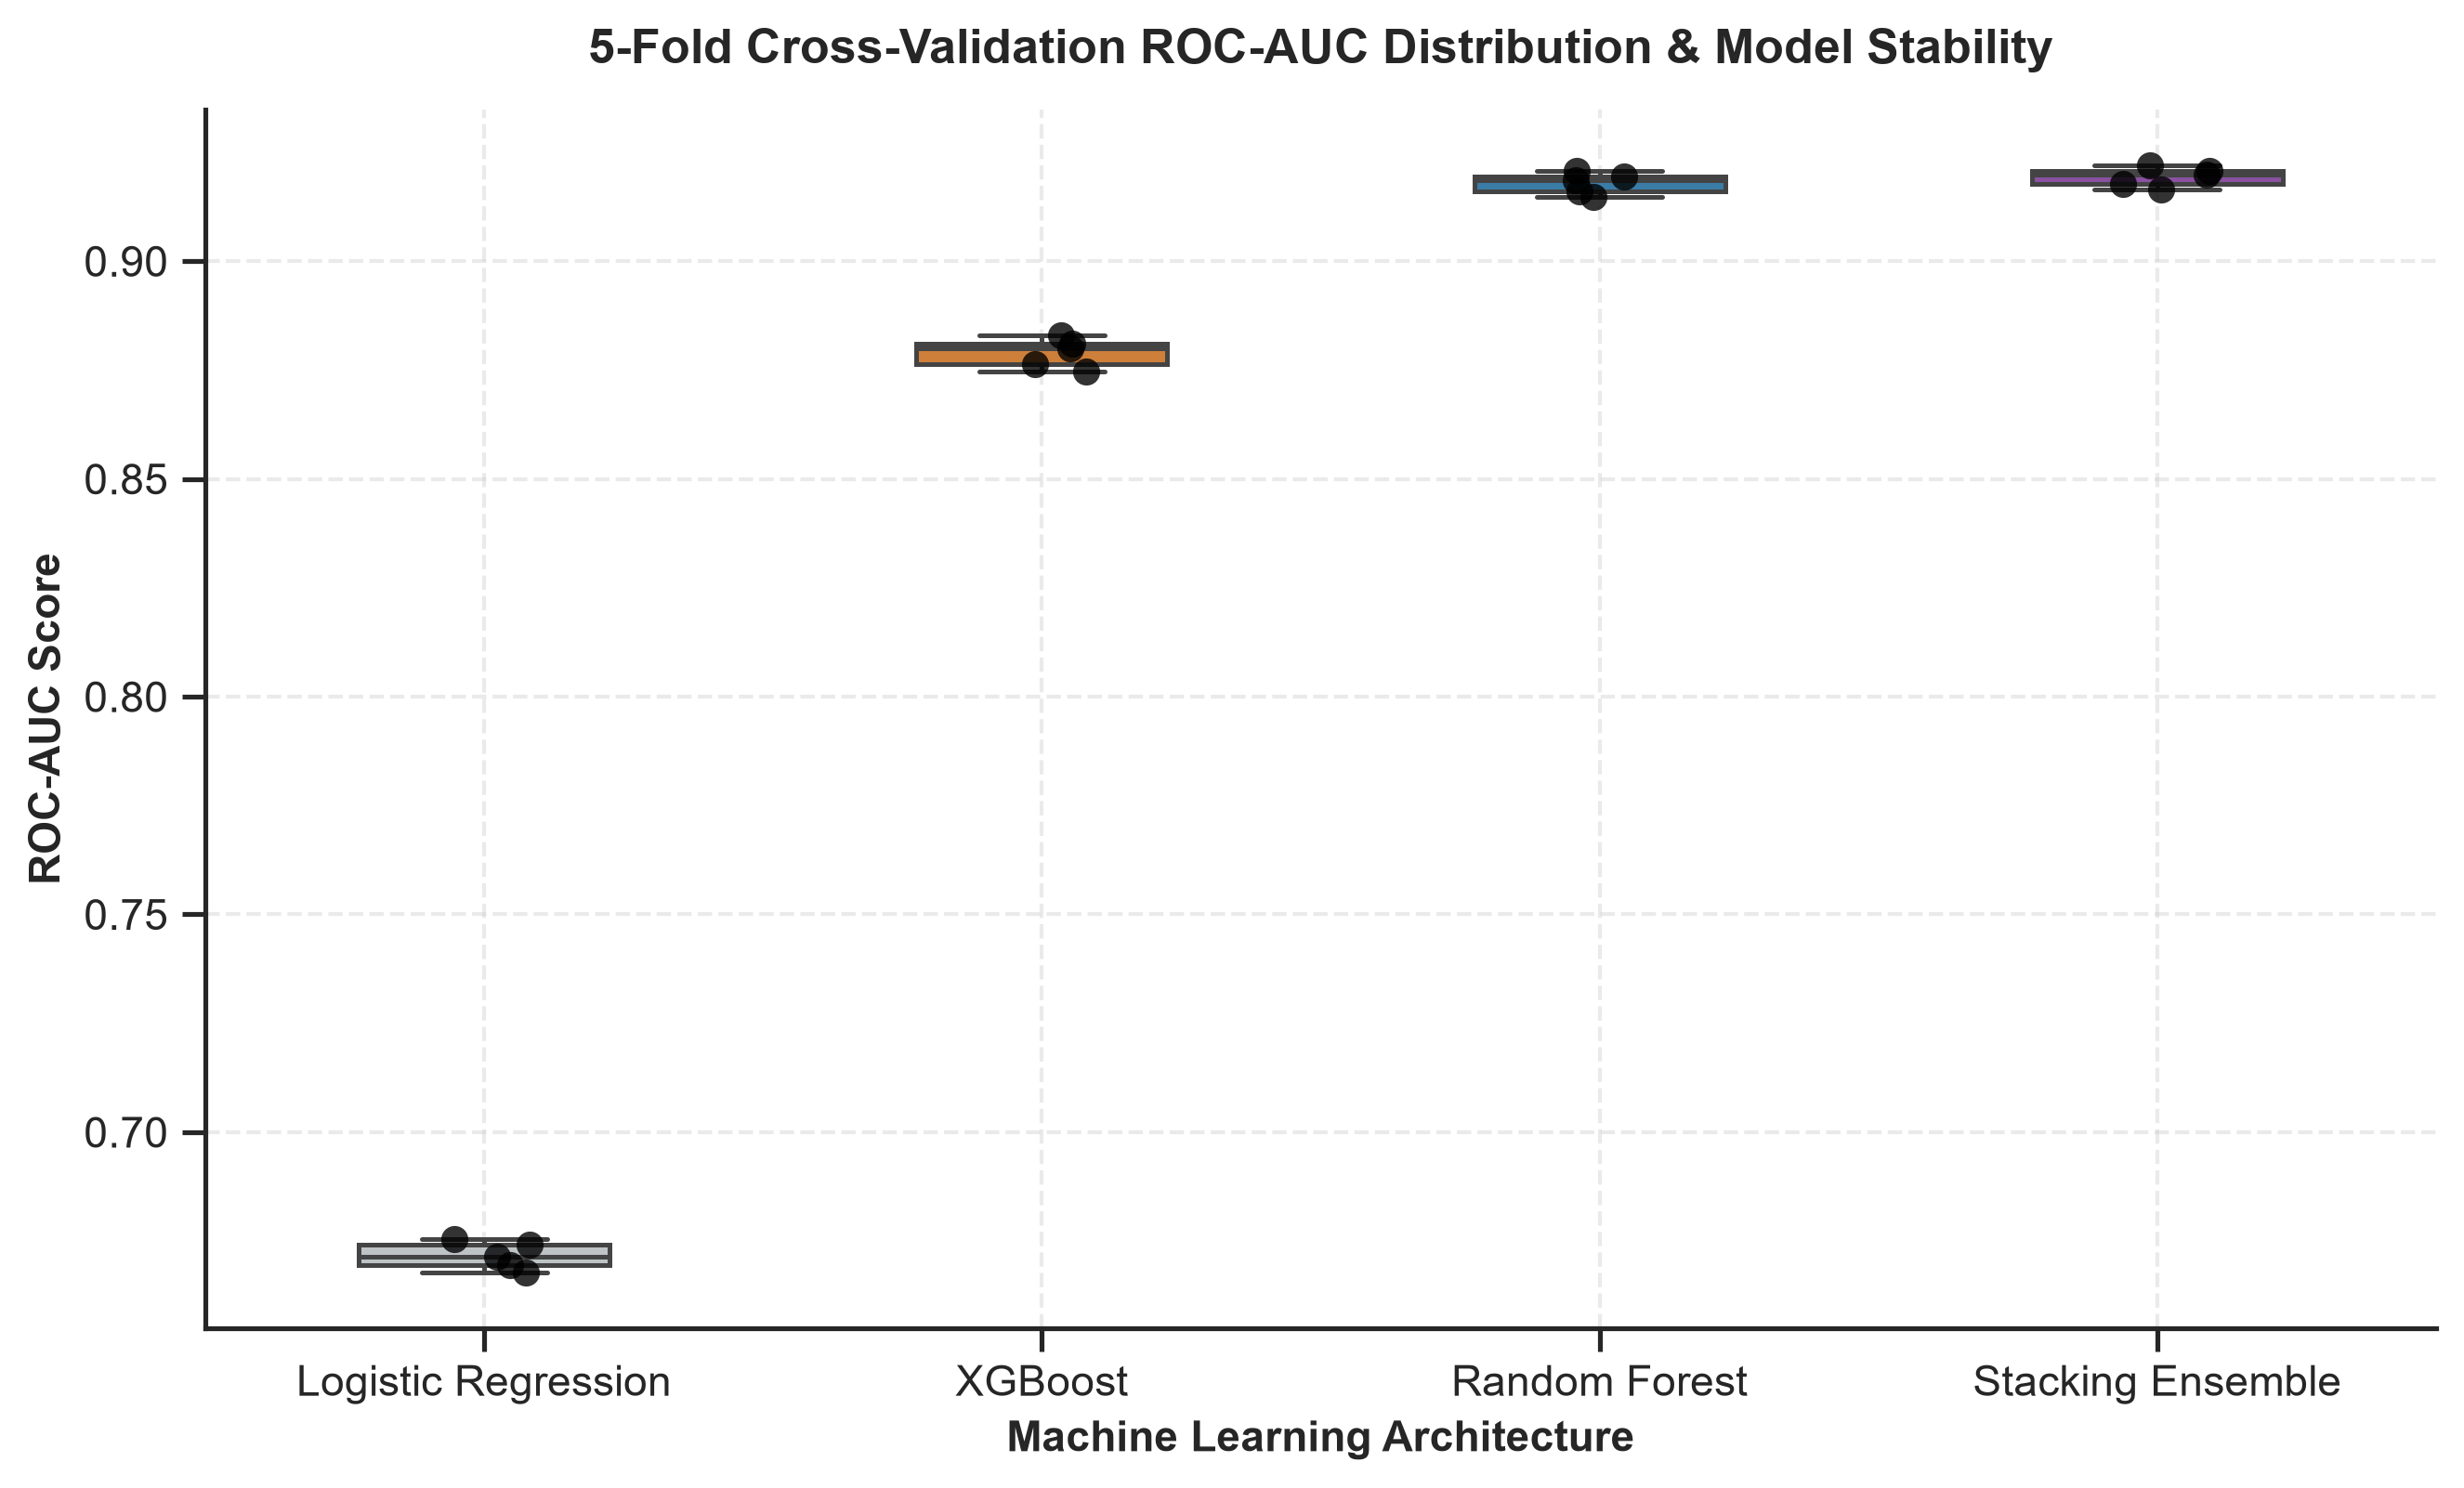

In [3]:
sns.set_theme(style="ticks", font="sans-serif")
plt.figure(figsize=(9, 5.5), dpi=300)
auc_df = pd.DataFrame(fold_auc)
sns.boxplot(data=auc_df, palette=["#BDC3C7", "#E67E22", "#2980B9", "#8E44AD"], width=0.45, linewidth=1.2)
sns.stripplot(data=auc_df, color="black", size=7, jitter=0.1, alpha=0.8)
plt.title("5-Fold Cross-Validation ROC-AUC Distribution & Model Stability", fontsize=12.5, fontweight="bold", pad=12)
plt.ylabel("ROC-AUC Score", fontsize=11, fontweight="bold")
plt.xlabel("Machine Learning Architecture", fontsize=11, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## 4. Financial ROI & Cost-Benefit Optimization

• Optimal Financial Decision Threshold:   0.40
• Expected Maximum Net Campaign Profit:   R$ 339,853.21


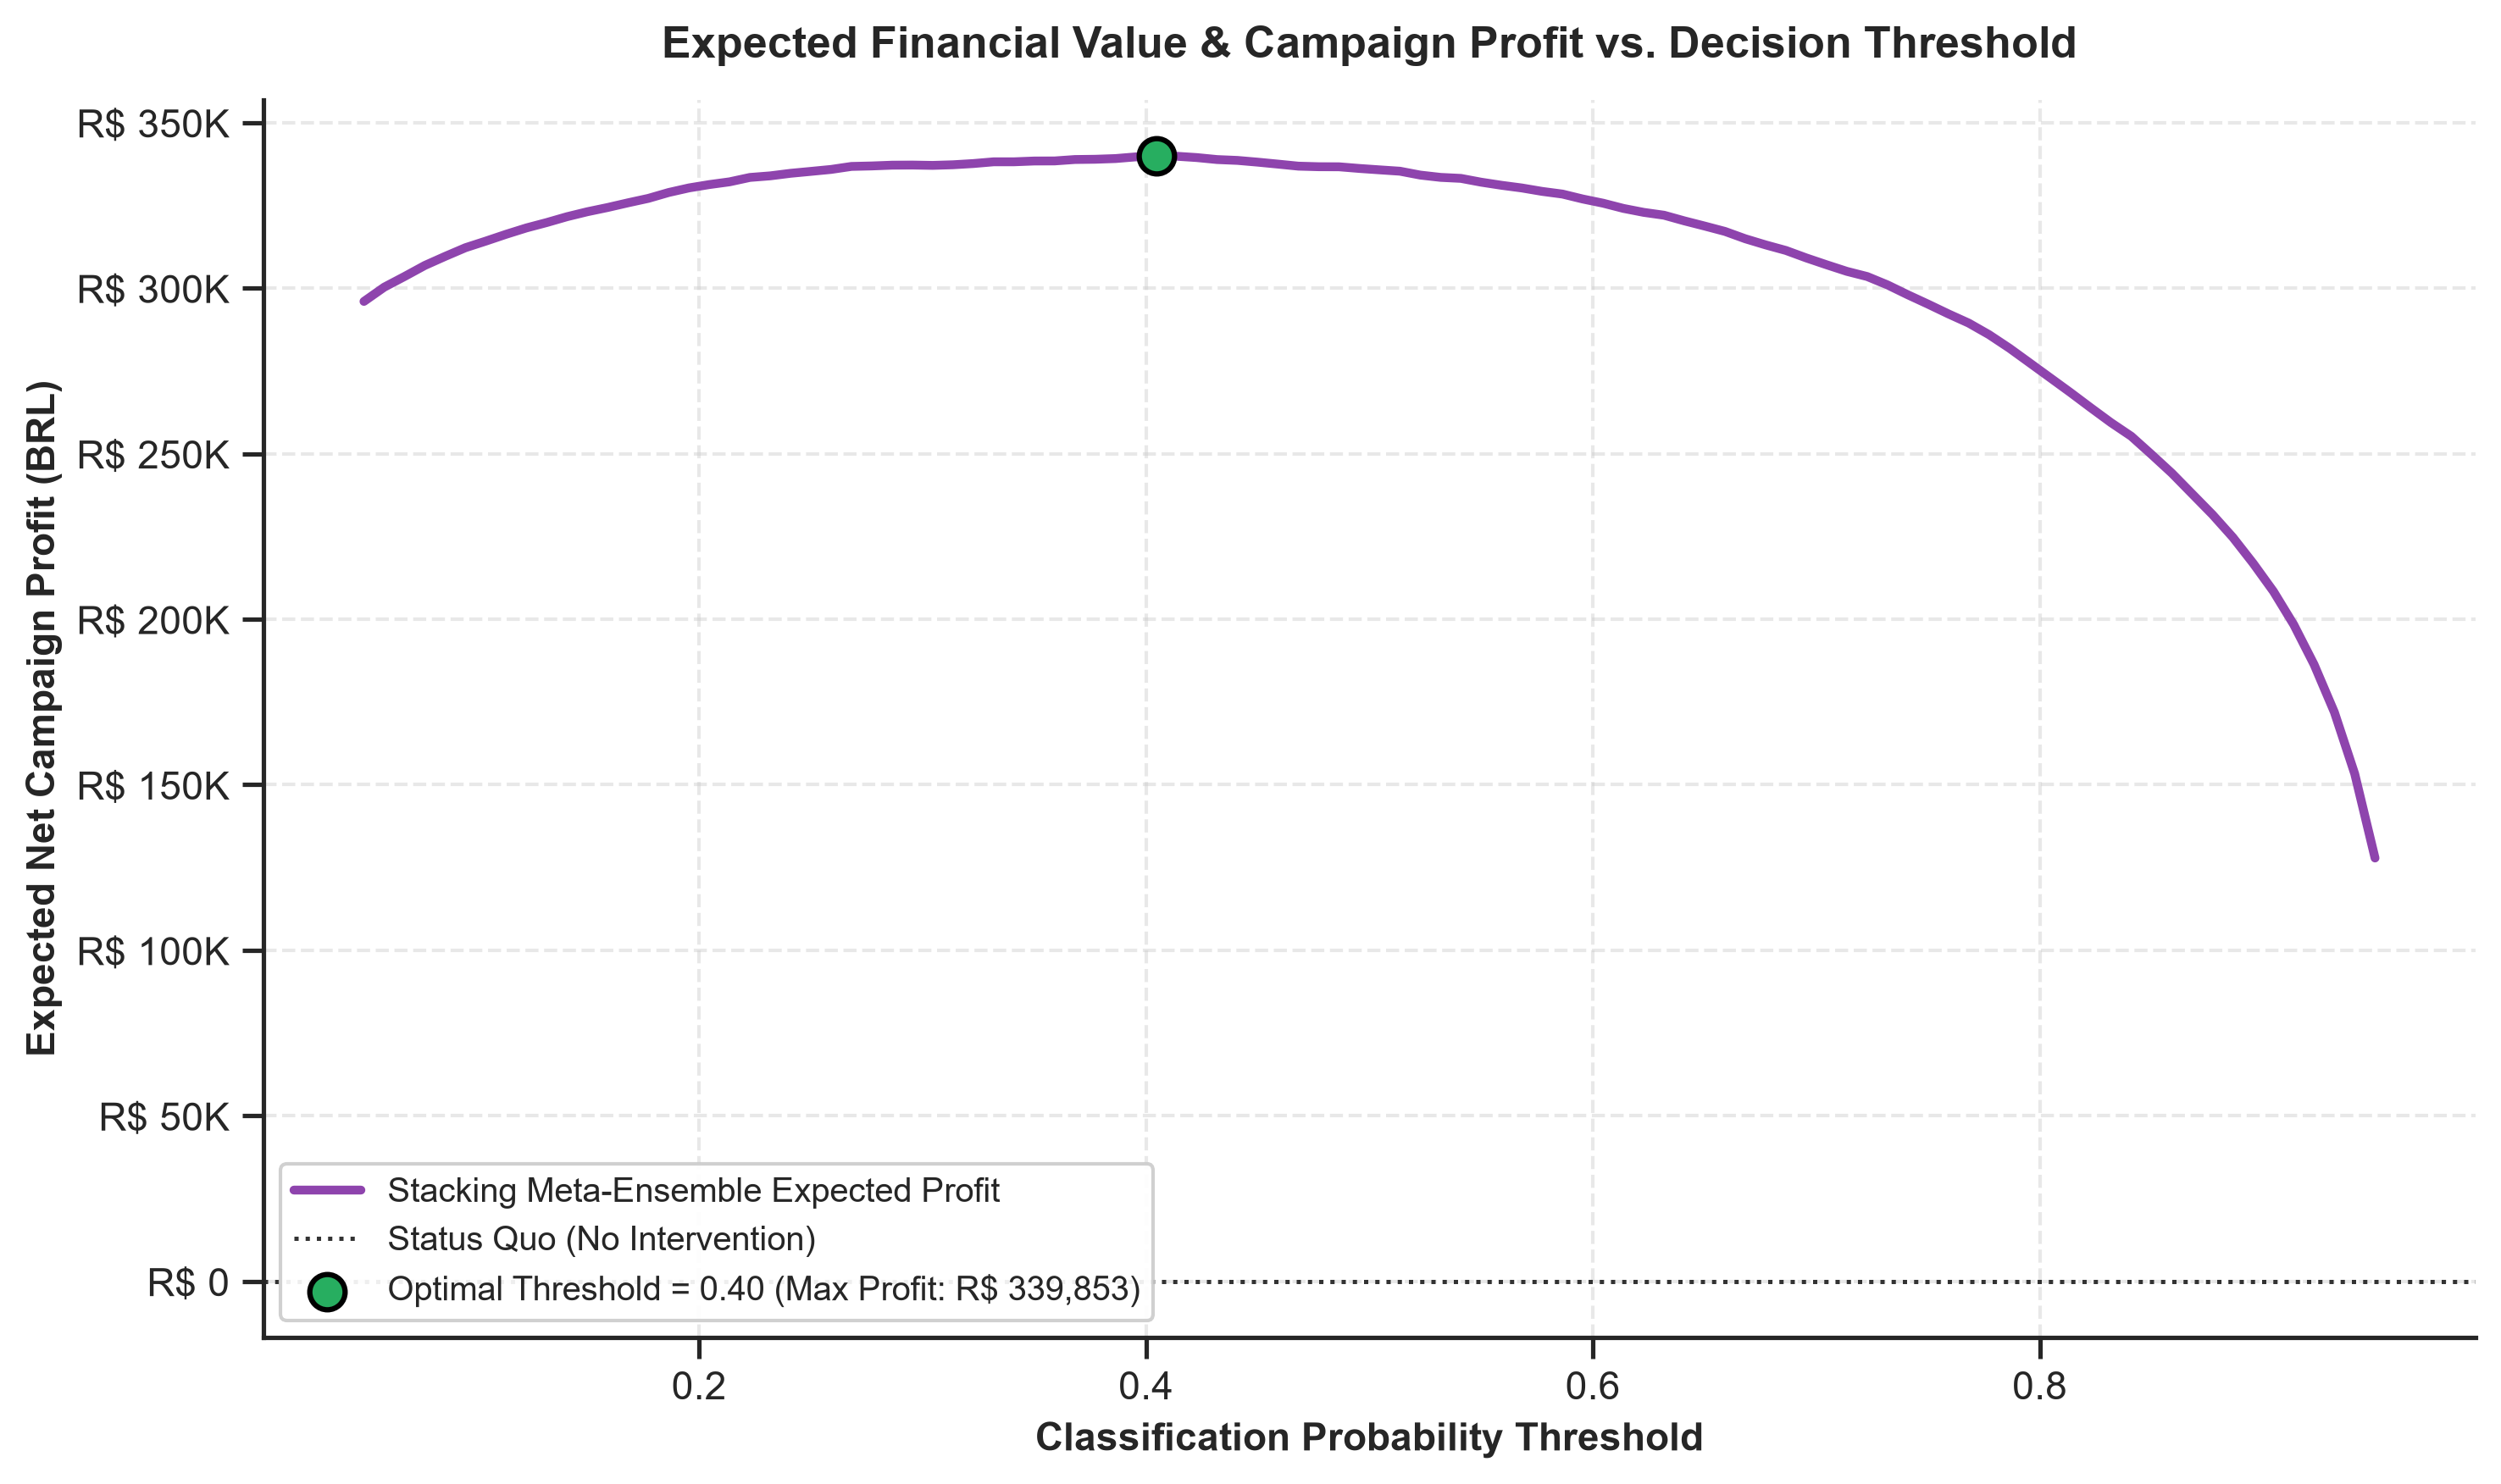

In [4]:
# Train-Test Split for Test Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
stack.fit(X_train, y_train)
test_probs = stack.predict_proba(X_test)[:, 1]

# Cost-Benefit Matrix Parameters
avg_ltv = 211.83          # Average LTV
cost_per_contact = 25.0   # Intervention cost
redemption_rate = 0.30    # 30% retention efficiency

candidate_thresholds = np.linspace(0.05, 0.95, 100)
profit_curve = []

for thresh in candidate_thresholds:
    preds = (test_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    targeted = tp + fp
    retained_rev = tp * redemption_rate * avg_ltv
    campaign_cost = targeted * cost_per_contact
    profit_curve.append(retained_rev - campaign_cost)

profit_curve = np.array(profit_curve)
max_idx = np.argmax(profit_curve)
opt_financial_threshold = candidate_thresholds[max_idx]
max_profit = profit_curve[max_idx]

print(f"• Optimal Financial Decision Threshold:   {opt_financial_threshold:.2f}")
print(f"• Expected Maximum Net Campaign Profit:   R$ {max_profit:,.2f}")

# Plot Financial Profit Curve
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(candidate_thresholds, profit_curve, color="#8E44AD", linewidth=2.5, label="Stacking Meta-Ensemble Expected Profit")
plt.axhline(0, color="#333333", linestyle=":", linewidth=1.2, label="Status Quo (No Intervention)")

plt.scatter([opt_financial_threshold], [max_profit], color="#27AE60", s=100, zorder=5, edgecolor="black", linewidth=1.5,
            label=f"Optimal Threshold = {opt_financial_threshold:.2f} (Max Profit: R$ {max_profit:,.0f})")

plt.title("Expected Financial Value & Campaign Profit vs. Decision Threshold", fontsize=12.5, fontweight="bold", pad=12)
plt.xlabel("Classification Probability Threshold", fontsize=11, fontweight="bold")
plt.ylabel("Expected Net Campaign Profit (BRL)", fontsize=11, fontweight="bold")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"R$ {x/1e3:.0f}K" if abs(x)>=1000 else f"R$ {x:.0f}"))
plt.grid(True, linestyle="--", alpha=0.45)
plt.legend(loc="lower left", frameon=True, framealpha=0.92, fontsize=9.5)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()